In [1]:
# 1. Bring in our toolboxes
import pandas as pd
import numpy as np
import random
import networkx as nx

print("Tools loaded! Generating employee data...")

# 2. Create fake UK HR data
np.random.seed(42)
num_employees = 200
employee_ids = range(1, num_employees + 1)

hr_data = pd.DataFrame({
    'Emp_ID': employee_ids,
    'Region': np.random.choice(['London', 'Manchester', 'Birmingham', 'Edinburgh'], num_employees),
    'Work_Model': np.random.choice(['Remote', 'Hybrid', 'Office'], num_employees),
    'Tenure_Years': np.random.randint(1, 15, num_employees),
    'Past_KPI_Score': np.random.randint(50, 100, num_employees),
    'High_Performer': np.random.choice([0, 1], num_employees, p=[0.7, 0.3])
})

# 3. Create fake communication logs (who talks to whom)
communications = []
for _ in range(800):
    sender = random.choice(employee_ids)
    receiver = random.choice(employee_ids)
    if sender != receiver:
        weight = random.randint(1, 50)
        communications.append({'Sender': sender, 'Receiver': receiver, 'Weight': weight})

comm_df = pd.DataFrame(communications)
print("Data generated successfully! You now have 200 fake employees.")

Tools loaded! Generating employee data...
Data generated successfully! You now have 200 fake employees.


In [2]:
print("Mapping the corporate network...")

# 1. Build the network map
G = nx.from_pandas_edgelist(comm_df, source='Sender', target='Receiver', edge_attr='Weight')

# 2. Calculate Social Network Analysis (SNA) scores
sna_features = pd.DataFrame({
    'Emp_ID': list(nx.degree_centrality(G).keys()),
    'Degree_Centrality': list(nx.degree_centrality(G).values()),
    'Betweenness_Centrality': list(nx.betweenness_centrality(G).values()),
    'Closeness_Centrality': list(nx.closeness_centrality(G).values())
})

# 3. Combine HR data with Network data
full_data = pd.merge(hr_data, sna_features, on='Emp_ID', how='left')
full_data.fillna(0, inplace=True) # Fill blanks with zero

print("Network mapped! Here are the first 5 employees:")
display(full_data.head()) # 'display' shows us a neat table in Colab

Mapping the corporate network...
Network mapped! Here are the first 5 employees:


,Emp_ID,Region,Work_Model,Tenure_Years,Past_KPI_Score,High_Performer,Degree_Centrality,Betweenness_Centrality,Closeness_Centrality
0,1,Birmingham,Office,1,52,0,0.040201,0.007613,0.365138
1,2,Edinburgh,Office,14,50,0,0.065327,0.025476,0.401210
2,3,London,Remote,5,82,0,0.040201,0.009314,0.359855
3,4,Birmingham,Remote,3,89,0,0.030151,0.006079,0.344291
4,5,Birmingham,Hybrid,12,59,0,0.030151,0.005600,0.353464


Training the AI... this takes a few seconds...

--- RESULTS ---
Accuracy Score: 50.0 %


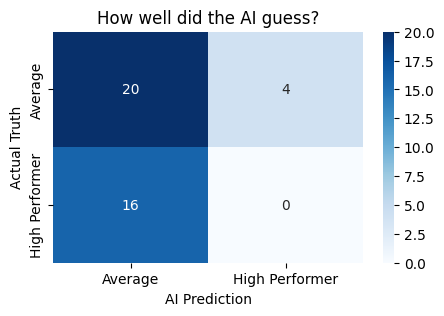

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prep the data (Computers need numbers, so we turn 'London' into binary 0s and 1s)
model_data = pd.get_dummies(full_data, columns=['Region', 'Work_Model'], drop_first=True)
X = model_data.drop(columns=['Emp_ID', 'High_Performer']) # Features
y = model_data['High_Performer'] # What we want to predict

# 2. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Set up the AI and give it settings to test
print("Training the AI... this takes a few seconds...")
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
}

# 4. Find the best settings and train
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

# 5. Make predictions on the test test
y_pred = best_model.predict(X_test)

# 6. Show the results!
print("\n--- RESULTS ---")
print("Accuracy Score:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

# 7. Draw the Confusion Matrix
plt.figure(figsize=(5,3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Average', 'High Performer'], yticklabels=['Average', 'High Performer'])
plt.ylabel('Actual Truth')
plt.xlabel('AI Prediction')
plt.title('How well did the AI guess?')
plt.show()

Calculating layout... arranging 200 employees...
Graph ready! The larger the circle, the more connected the employee is.


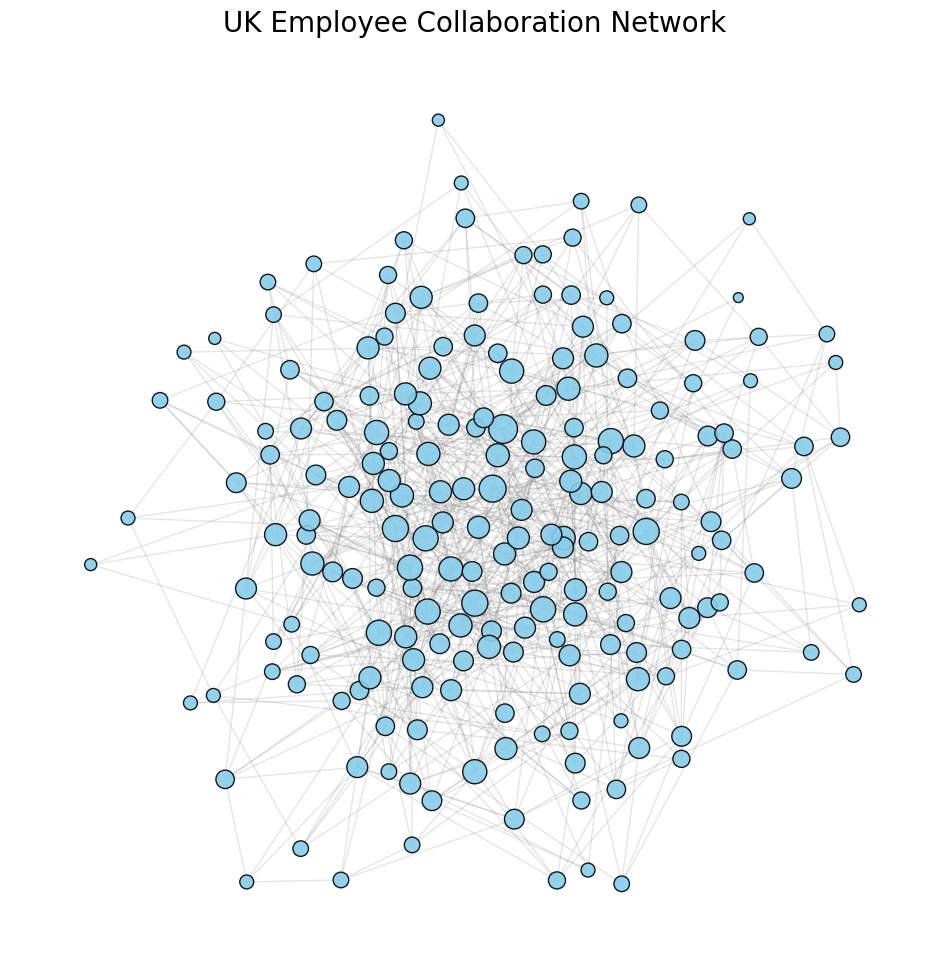

In [4]:
# 1. Set up a large blank canvas
plt.figure(figsize=(12, 12))
plt.title("UK Employee Collaboration Network", fontsize=20)

# 2. Choose a layout for the spiderweb
# The 'spring_layout' pushes connected people together and pushes unconnected people apart
print("Calculating layout... arranging 200 employees...")
pos = nx.spring_layout(G, k=0.15, iterations=20, seed=42)

# 3. Size the dots based on how connected they are
# We multiply their centrality score by 5000 so the dots are big enough to see!
degree_dict = nx.degree_centrality(G)
node_sizes = [degree_dict[node] * 5000 for node in G.nodes()]

# 4. Draw the Employees (Nodes)
nx.draw_networkx_nodes(G, pos,
                       node_size=node_sizes,
                       node_color='skyblue',
                       alpha=0.9,
                       edgecolors='black')

# 5. Draw the Communications (Edges)
nx.draw_networkx_edges(G, pos,
                       alpha=0.2, # Makes the lines slightly transparent
                       edge_color='gray')

# 6. Turn off the graph borders for a clean look and show the plot!
plt.axis('off')
print("Graph ready! The larger the circle, the more connected the employee is.")
plt.show()

In [5]:
import joblib
from google.colab import files

print("Packaging files for download...")

# 1. Save and download the dataset
full_data.to_csv('uk_employee_data.csv', index=False)
files.download('uk_employee_data.csv')

# 2. Save and download the trained AI model
joblib.dump(best_model, 'employee_performance_model.pkl')
files.download('employee_performance_model.pkl')

print("Check your computer's Downloads folder!")

Packaging files for download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Check your computer's Downloads folder!
